In [85]:
# This notebook gets the ET from SSebop method (https://earlywarning.usgs.gov/ssebop/modis)
# Initial results of ET from MODIS suggests, that MODIS ET could be overestimating for souteast Texas
# (sub-watershed in Neches basin). Here, SSebop is explored as a different "benchmark" ET to better understand the
# accuracy of MODIS ET products

In [86]:
# Import package
import rasterio
import rasterio.plot as rp
from rasterio.plot import show
# from rasterio.plot import show, add_colorbar
import geopandas as gpd
from rasterio.mask import mask
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
# import ipympl
from matplotlib.transforms import Affine2D

In [87]:
# Read the USGS ID for all the gages in the Neches River Basin (see get_basins_streamflow_neches.ipynb)
list_gauges = pd.read_csv('../data-processed/basin/List_gaugeID.csv')
list_gauges = list_gauges['gauge_ID'] 
# Add a zero at the beginning of the gauge ID
list_gauges = ['0' + str(i) for i in list_gauges]

# Get watershed domain
gauge_ID = list_gauges[10] # 11 neches, 10 Village
# watershed_gauge = NLDI().get_basins(gauge_ID)
# watershed_gauge.to_file(f'../data-processed/basin/watershed_gaugeID_{gauge_ID}.shp')
# Load basin shapefile
watershed_gauge = gpd.read_file(f'../data-processed/basin/watershed_gaugeID_{gauge_ID}.shp')

In [88]:
# Create an empty dataframe to save results
df = pd.DataFrame(columns=['ET', 'year', 'month', 'day'])
# Create a a daily time vector for 2016
time = pd.date_range(start='2013-01-01', end='2018-12-31', freq='D')
# populate dataframe with time vector
df['year'] = time.year
df['month'] = time.month
df['day'] = time.day
# Create a index time vector
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
# create a colum with date format YYYYDDD
df['date_str'] = df['date'].dt.strftime('%Y%j')


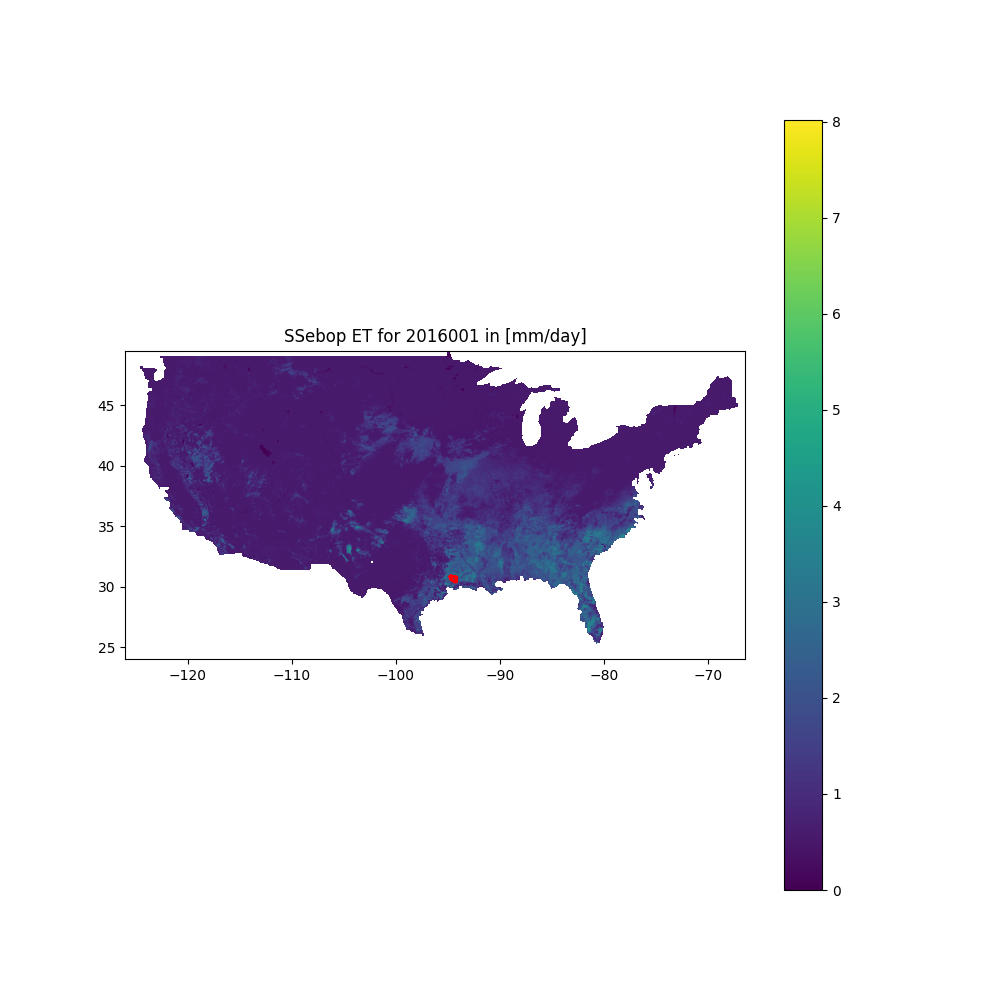

In [89]:
# Plot an example of the ET raster

Year = '2016'
Day = '001'

# Open the TIF file
with rasterio.open(f'/Users/gpq/ORNL/Databases/ET_SSEbop/{Year}/det{Year}{Day}.modisSSEBopETactual/det{Year}{Day}.modisSSEBopETactual.tif') as src:

    fig, ax = plt.subplots(figsize=(10, 10))
    transform = src.transform
    nodata = src.nodata
    data = src.read(1)
    data = np.where(data == 9999, np.nan, data)
    left, bottom = transform * (0, src.height)
    right, top = transform * (src.width, 0)
    base1 = plt.imshow(data/1000, cmap='viridis', extent=[left, right, bottom, top])
    fig.colorbar(base1, ax=ax)

    watershed_gauge.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)
    # set title
    plt.title(f'SSebop ET for {Year}{Day} in [mm/day]')
    plt.show()

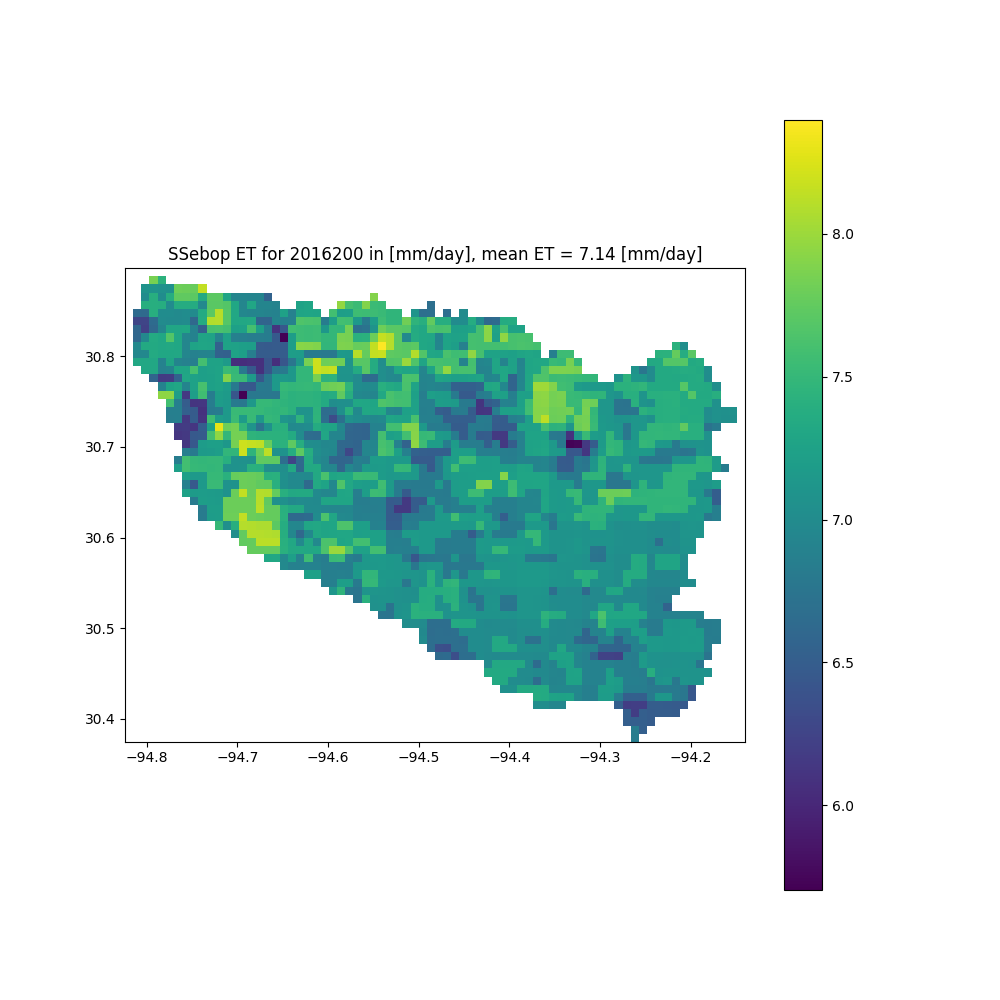

In [90]:
# Plot an example of the ET raster

Year = '2016'
Day = '200'

# Open the TIF file
# with rasterio.open(f'/Users/gpq/ORNL/Databases/ET_SSEbop/{Year}/det{Year}{Day}.modisSSEBopETactual/det{Year}{Day}.modisSSEBopETactual.tif') as src:
with zipfile.ZipFile(f'/Users/gpq/ORNL/Databases/ET_SSEbop/{Year}/det{Year}{Day}.modisSSEBopETactual.zip', 'r') as zip_ref:
    # Get the list of files in the zip file
    file_list = zip_ref.namelist()
    # Find the TIF file in the zip file
    tif_file = zip_ref.open(file_list[0])
    dataset = rasterio.open(tif_file)    
    # Clip the TIF file using the watershed boundary
    clipped, transform = mask(dataset, watershed_gauge.geometry, crop=True)
    clipped = np.where(clipped == 9999, np.nan, clipped)
    # plot clipped data
    fig, ax = plt.subplots(figsize=(10, 10))
    left, bottom = transform * (0, clipped.shape[1])
    right, top = transform * (clipped.shape[2], 0)
    base1 = plt.imshow(clipped[0]/1000, cmap='viridis', extent=[left, right, bottom, top])
    fig.colorbar(base1, ax=ax)
    # set title
    plt.title(f'SSebop ET for {Year}{Day} in [mm/day], mean ET = {np.nanmean(clipped[0]/1000):.2f} [mm/day]')
    plt.show()


In [91]:
# Do loop for each date
# for i in range(0, 1):
for i in range(len(df)):
    # print(i)
    # Open the zip file
    Year = df['year'][i]
    Date_str = df['date_str'][i]
    with zipfile.ZipFile(f'/Users/gpq/ORNL/Databases/ET_SSEbop/{Year}/det{Date_str}.modisSSEBopETactual.zip', 'r') as zip_ref:
        # Get the list of files in the zip file
        file_list = zip_ref.namelist()
        # Find the TIF file in the zip file
        tif_file = zip_ref.open(file_list[0])
        dataset = rasterio.open(tif_file)
        # Clip the TIF file using the watershed boundary
        ET_SSebop, transform = mask(dataset, watershed_gauge.geometry, crop=True)
        ET_SSebop = np.where(ET_SSebop == 9999, np.nan, ET_SSebop)
    # compute the mean value and save it in a dataframe
    # Get the mean value of ET
    df['ET'][i] = np.nanmean(ET_SSebop)/1000 # [mm/day]           


/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_19476/246227810.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ET'][i] = np.nanmean(ET_SSebop)/1000 # [mm/day]
/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_19476/246227810.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ET'][i] = np.nanmean(ET_SSebop)/1000 # [mm/day]
/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_19476/246227810.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

In [92]:
np.max(df['ET'])

8.262976816074188

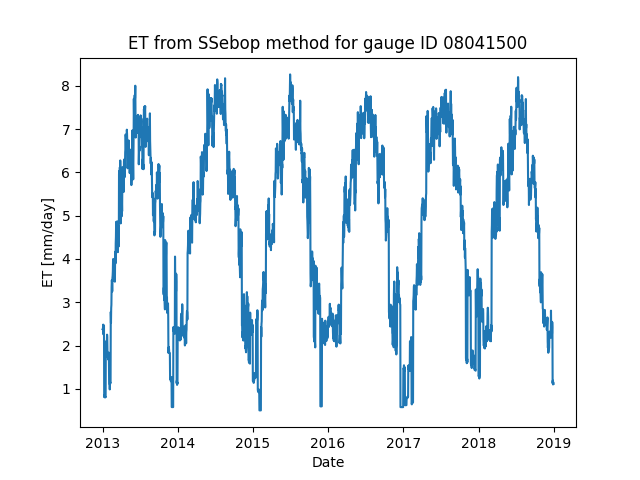

In [93]:
# Plot time series
fig = plt.figure()
plt.plot(df['date'], df['ET'])
plt.xlabel('Date')
plt.ylabel('ET [mm/day]')
plt.title(f'ET from SSebop method for gauge ID {gauge_ID}')
plt.show()

In [94]:
# save dataframe
df.to_csv(f'../data-processed/ET_SSebop/ET_SSEbop_{gauge_ID}.csv', index=False)

In [95]:
np.nanmean(df['ET'])*365



1753.5403683124487